<a href="https://colab.research.google.com/github/harishmk31/24ADI003_24BAD031/blob/main/scenario2_exp8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Harish MK - 24BAD031
Explained Variance Ratio:
[0.72962445 0.22850762 0.03668922 0.00517871]
Cumulative Variance:
[0.72962445 0.95813207 0.99482129 1.        ]


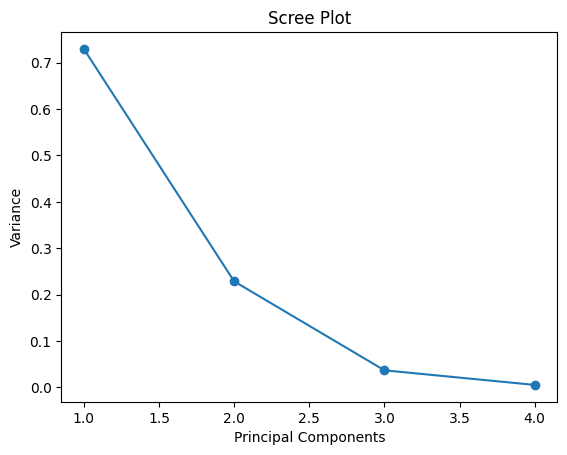

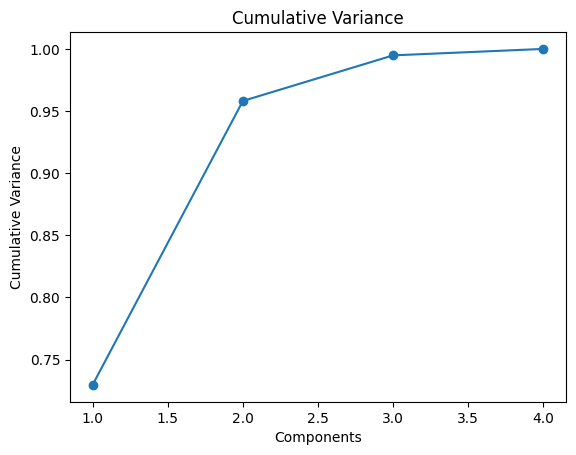

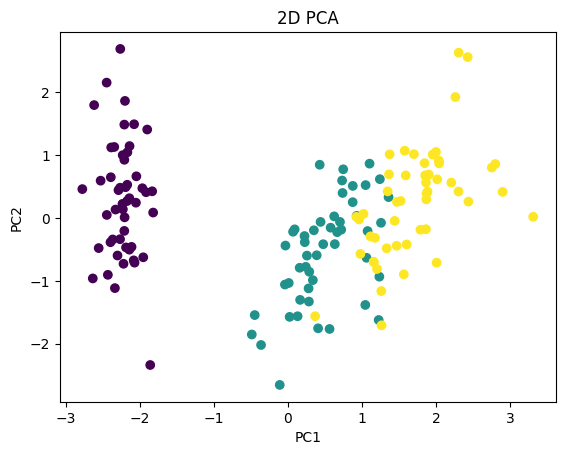

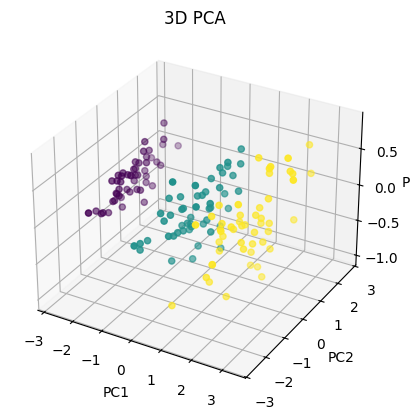

Optimal components for 95% variance:
2
Original Shape: (150, 4)
Reduced Shape 2D: (150, 2)
Reduced Shape 3D: (150, 3)


In [2]:
print("Harish MK - 24BAD031")

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D

data = load_iris()
df = pd.DataFrame(data.data, columns=data.feature_names)
target = data.target

df = df.dropna()

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

pca = PCA()
pca_data = pca.fit_transform(scaled_data)

explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

print("Explained Variance Ratio:")
print(explained_variance)

print("Cumulative Variance:")
print(cumulative_variance)

pca_2 = PCA(n_components=2)
pca_2d = pca_2.fit_transform(scaled_data)

pca_df_2d = pd.DataFrame(data=pca_2d, columns=["PC1", "PC2"])

pca_3 = PCA(n_components=3)
pca_3d = pca_3.fit_transform(scaled_data)

pca_df_3d = pd.DataFrame(data=pca_3d, columns=["PC1", "PC2", "PC3"])

plt.figure()
plt.plot(range(1, len(explained_variance)+1), explained_variance, marker='o')
plt.xlabel("Principal Components")
plt.ylabel("Variance")
plt.title("Scree Plot")
plt.show()

plt.figure()
plt.plot(range(1, len(cumulative_variance)+1), cumulative_variance, marker='o')
plt.xlabel("Components")
plt.ylabel("Cumulative Variance")
plt.title("Cumulative Variance")
plt.show()

plt.figure()
plt.scatter(pca_df_2d["PC1"], pca_df_2d["PC2"], c=target)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("2D PCA")
plt.show()

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(pca_df_3d["PC1"], pca_df_3d["PC2"], pca_df_3d["PC3"], c=target)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title("3D PCA")

plt.show()

print("Optimal components for 95% variance:")
print(np.argmax(cumulative_variance >= 0.95) + 1)

print("Original Shape:", df.shape)
print("Reduced Shape 2D:", pca_df_2d.shape)
print("Reduced Shape 3D:", pca_df_3d.shape)